In [ ]:
#################################################
################  Import things #################
#################################################

import numpy as np
import timeit
import random
import copy
import matplotlib.pyplot as plt
from sklearn import datasets
import pickle
from scipy import stats
import glycowork
import pandas as pd


from scipy.stats import dirichlet
#import dirichlet as dirichlet_mle #https://github.com/ericsuh/dirichlet

from glycowork.glycan_data.loader import glycan_binding as gb
from glycowork.glycan_data.loader import df_glycan as df_glycan


In [44]:
gb.head() # 2745 columns are glycans, 1465 rows are lectins, entries are rel fluour unit Z-scores.  NaNs can be taken to zero


,3-Anhydro-Gal(a1-3)Gal(b1-4)3-Anhydro-Gal(a1-3)Gal4S,3-Anhydro-Gal(a1-3)Gal4S(b1-4)3-Anhydro-Gal(a1-3)Gal4S,3-Anhydro-Gal(a1-3)Gal4S(b1-4)3-Anhydro-Gal(a1-3)Gal4S(b1-4)3-Anhydro-Gal(a1-3)Gal4S,3-Anhydro-Gal(a1-3)Gal4S(b1-4)3-Anhydro-Gal(a1-3)Gal4S(b1-4)3-Anhydro-Gal(a1-3)Gal4S(b1-4)3-Anhydro-Gal(a1-3)Gal4S,3-Anhydro-Gal(a1-3)Gal4S(b1-4)3-Anhydro-Gal2S(a1-3)Gal4S(b1-4)3-Anhydro-Gal(a1-3)Gal4S,3dGal(b1-3)[Fuc(a1-4)]Glc,3dGal(b1-4)Glc,4d8dNeu5Ac(a2-3)Gal(b1-4)Glc,4dNeu5Ac(a2-3)Gal(b1-4)Glc,7dNeu5Ac(a2-3)Gal(b1-4)Glc,...,wwwSflexneri5c,wwwSflexneriO2c,wwwSflexneriO5c,wwwSisomicin,wwwSmix,wwwTobramycin,wwwTyrS,wwwpHGGs,target,protein
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,AADSIPSISPTGIITPTPTQSGMVSNCNKFYDVHSNDGCSAIASSQ...,TAL6-4LysM
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,AAFFSLVVLLALLPFGIHASALPSTELTPRVNPNLPGPNDVFVGFR...,rCnSL-proA
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,AANEADYQAKLTAYQTELARVQKANADAKAAYEAAVAANNAANAAL...,AntigenI/IIA3VP1
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,AASKLGVPQPAQRDQVNCQLYAVQPNDNCIDISSKNNITYAQLLSW...,TAL6-6LysM
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ACNNEWEDEQYEQYISFKSPIPAGGEGVTDIYVRYKEDGKVTYRLP...,SP15308A-bot-339-19-339


In [45]:
gb.target # this column shows the amino acide sequence of the 1465 lectins

0       AADSIPSISPTGIITPTPTQSGMVSNCNKFYDVHSNDGCSAIASSQ...
1       AAFFSLVVLLALLPFGIHASALPSTELTPRVNPNLPGPNDVFVGFR...
2       AANEADYQAKLTAYQTELARVQKANADAKAAYEAAVAANNAANAAL...
3       AASKLGVPQPAQRDQVNCQLYAVQPNDNCIDISSKNNITYAQLLSW...
4       ACNNEWEDEQYEQYISFKSPIPAGGEGVTDIYVRYKEDGKVTYRLP...
                              ...                        
1460    YGAPAGPLIVPYNLPLPGGVVPRMLITILGTVKPNANRIALDFQRG...
1461    YIGDFRCIQLVNSNGANVSAPSISTETVEVSQGLGTYYVLDRVYLN...
1462    YKLVCYFTQWSQDRQEPGKFTPENIDPFLCSHLIYSFASIENNKVI...
1463    YRRTCSHTGKGEGWYIIRRGDNFNAVAADFCTSTNVLTEWNHISTI...
1464    YVDVGPDSVKSACIEVDIQQTFFDKTWPRPIDVSKADGIIYPQGRT...
Name: target, Length: 1465, dtype: object

In [ ]:
from glycowork.ml.models import prep_model
from glycowork.ml import inference

glycans_in_gb = list(gb.columns)[0:-2] # last two columns ('target' and 'protein') are not glycans

sn = prep_model('SweetNet', 1011, trained = True) # this retrieves the trained model (needs to download)
sn_df = inference.glycans_to_emb(glycans_in_gb, sn) # embeddings are 128 dimensional vectors

sn_df # 2743 glycans x 128 dimensions


,0,1,2,3,4,5,6,7,8,9,...,118,119,120,121,122,123,124,125,126,127
0,0.213248,-0.027729,0.492947,0.037481,-0.024913,0.404567,0.421238,-0.083318,-0.068460,0.189522,...,0.616861,0.117871,-0.693637,0.108677,-0.153195,0.225896,-1.528042,-0.319901,-1.307314,0.019371
1,-1.549530,-0.226507,-0.459042,-0.894130,0.667302,-1.041203,-1.667286,-0.082475,-2.012239,1.065641,...,-1.635057,-0.344074,-0.476931,1.699936,0.114313,0.455085,-0.851357,-1.624757,-3.461320,1.534258
2,-1.894989,-0.307849,-0.348715,-0.699440,0.677197,-1.289638,-1.782711,-0.044384,-2.255064,1.123431,...,-1.739209,-0.653298,-0.679384,1.671777,0.021103,0.194384,-1.002065,-1.760719,-3.680750,1.672488
3,-2.054815,-0.338438,-0.293592,-0.612321,0.672682,-1.406358,-1.854457,-0.024568,-2.369451,1.132581,...,-1.801254,-0.812276,-0.791281,1.648174,-0.042687,0.073665,-1.087165,-1.836039,-3.792380,1.748271
4,-1.624540,-0.266217,-0.152833,-0.319358,0.655027,-1.045889,-1.440265,0.239041,-1.962662,0.995113,...,-2.138041,-0.555154,-0.511841,1.584810,-0.441665,0.126610,-0.501003,-1.702151,-3.384598,1.465940
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2738,-0.245793,-0.219968,-1.083026,0.703660,0.014054,-0.496685,-0.469979,0.910069,0.463466,0.753838,...,-0.769342,0.555219,0.933459,1.608508,-0.632020,-0.667751,0.645396,-0.229229,0.611576,-0.288226
2739,-0.348156,-0.626758,-0.593727,0.362953,0.443549,0.475912,0.182355,0.755839,0.940177,0.745954,...,0.304121,0.288745,0.462776,-0.087345,0.890322,-0.007732,-0.162308,0.046900,-0.516792,-0.901369
2740,-0.782112,-2.138604,-0.066338,-0.717154,0.442486,0.549591,-1.972164,0.381640,0.318718,-0.312513,...,-1.161525,0.890519,0.326795,-0.010886,-0.300535,0.082075,0.771093,-0.141941,0.002140,-0.888452
2741,-1.453987,-1.860012,-0.440452,-0.465135,0.569005,0.166841,-1.288206,0.222856,0.469307,0.221101,...,-0.853830,0.302022,0.591374,-0.377805,0.281732,-0.133411,0.630591,-0.324035,0.464135,-1.138010


In [ ]:
import esm.pretrained
from glycowork.ml.inference import get_esm1b_representations, get_lectin_preds
from glycowork.ml.models import prep_model

model, alphabet = esm.pretrained.esm1b_t33_650M_UR50S() # load ESM1b model,will need to download if the first time
leor = prep_model('LectinOracle', 1, trained = True) # prepare the pretrained LectinOracle model

filename = '/Users/csfloyd/Dropbox/Projects/GlycanAnalysis/Data/LectinOracleReps.pkl' # loading the ESM1b representations for the lectins is faster 
with open(filename, 'rb') as file:
    pre_computed_reps = pickle.load(file)


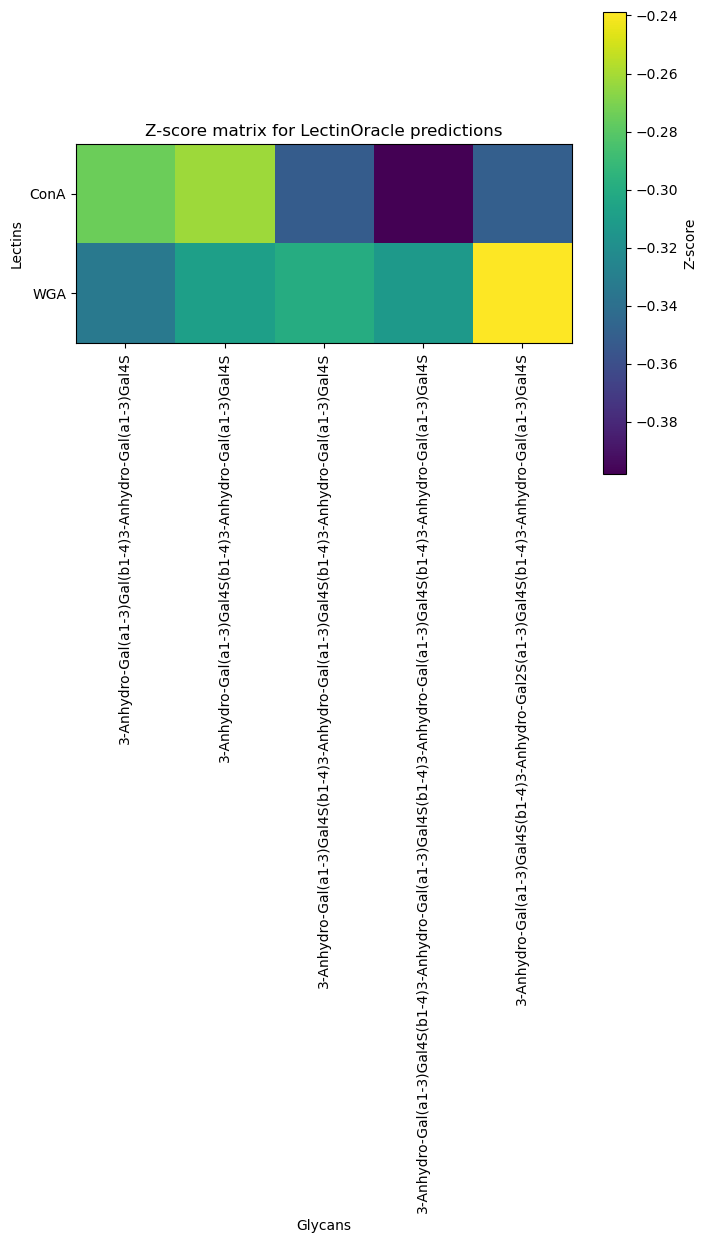

In [67]:
## which lectins to test
prot_seq_list = []
prot_names = ["ConA", "WGA"]
for prot_name in prot_names:
    prot_seq_list.append(gb[gb['protein'] == prot_name]['target'].iloc[0])

# which glycans to test
glycans_to_test = glycans_in_gb[0:5] 



n_gly = len(glycans_to_test)
n_prots = len(prot_seq_list)
z_score_mat = np.zeros((n_prots, n_gly))

use_precomputed_reps = True # faster to load the precomputed ESM1b reps

for (p, prot_seq) in enumerate(prot_seq_list):
    
    if use_precomputed_reps:
        rep = pre_computed_reps
    else:
        rep = get_esm1b_representations([prot_seq], model, alphabet)

    predictions = get_lectin_preds(prot_seq, glycans_to_test, leor, rep)
    z_scores = list([predictions['pred'][i] for i in range(len(predictions['pred']))])
    z_score_mat[p,:] = z_scores

plt.figure(figsize=(8,6))
plt.imshow(z_score_mat, cmap='viridis')
plt.xticks(range(n_gly), glycans_to_test, rotation=90)
plt.yticks(range(n_prots), prot_names)
plt.colorbar(label='Z-score')
plt.title('Z-score matrix for LectinOracle predictions')
plt.xlabel('Glycans')
plt.ylabel('Lectins')
plt.show()